# Green window scheduling

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import campaign_analysis as ca

plt.rcParams.update({"font.family": "serif", "font.size": 9, "figure.dpi": 110,
                     "axes.grid": True, "axes.axisbelow": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

REPO = Path.cwd().parent
OUT_DIR = REPO / "experiments" / "out"
CAMPAIGN_PATH = REPO / "experiments" / "experiments.toml"
INTENSITIES_DIR = REPO / "intensities"
WINDOWS_PATH = INTENSITIES_DIR / "windows.csv"
CEILING_PATH = REPO / "analysis" / "shift_ceiling_results.csv.gz"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

## Campaign

In [2]:
campaign, windows = ca.load_campaign(CAMPAIGN_PATH, WINDOWS_PATH)
print(f"{len(campaign)} experiments, {len(windows)} windows")

1008 experiments, 36 windows


## Completeness

In [3]:
result_files = ca.check_completeness(campaign, OUT_DIR)
print(f"{len(ca.missing_results(result_files))} incomplete")

0 incomplete


## Results

In [4]:
schedules, jobs = ca.load_results(campaign, result_files, OUT_DIR, windows)
job_metrics = ca.build_job_metrics(jobs)
run_metrics = ca.build_run_metrics(schedules, job_metrics, jobs)
print(f"schedules {schedules.shape}, jobs {jobs.shape}, run_metrics {run_metrics.shape}")
paired = ca.build_paired_comparisons(run_metrics)
deferral = ca.build_deferral_diagnostics(jobs, run_metrics)

schedules (1008, 49), jobs (6087060, 30), run_metrics (1008, 41)


## Trace validity

In [5]:
extent = ca.trace_extent(windows, INTENSITIES_DIR)
coverage = ca.trace_coverage(run_metrics, OUT_DIR, extent)
ca.assert_footprint_validity(coverage)
print(f"all {len(coverage)} runs finish inside their trace "
      f"(worst {coverage['makespan_over_trace'].max():.3f})")

all 1008 runs finish inside their trace (worst 0.766)


## Terms

**Improvement over EASY.** Each green run is compared with EASY in the same window. Positive values indicate improvement: lower footprint, energy, makespan, waiting time and slowdown, or higher utilisation.

**Platform intensity.** Operational footprint divided by total compute and idle energy, in gCO2eq/kWh for carbon or L/kWh for water.

**Compute intensity.** Footprint divided by energy for running jobs, using per-job totals such as `consumed_carbon` and `consumed_energy`. It measures the intensity of the selected execution periods.

**Idle intensity.** Footprint divided by energy for powered-on nodes that are not computing. Moving compute to cleaner periods leaves idle exposure in the displaced periods.

**Ceiling saving.** Saving relative to every job starting at submission, counting only its own nodes. EASY has a negative saving because this baseline excludes queueing.


## Against the offline ceiling

The bound in `shift_ceiling.ipynb` counts compute while running and idle while waiting on each job's own nodes. Its baseline starts every job at submission. `build_ceiling_costs` applies the same cost expression to achieved start times, placing EASY, green scheduling and the bound on the same scale. Savings use ratios of summed footprints, not medians of per-window percentages.


In [6]:
ceiling_costs = ca.build_ceiling_costs(jobs)
ceiling_comparison = ca.compare_with_ceiling(ceiling_costs, run_metrics, CEILING_PATH)

## Plot: trace coverage

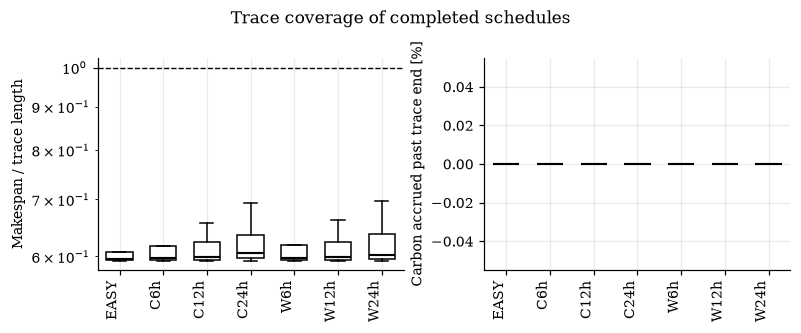

In [7]:
coverage_fig, _ = ca.plot_trace_coverage(coverage)
plt.show()

## Plot: improvement over EASY

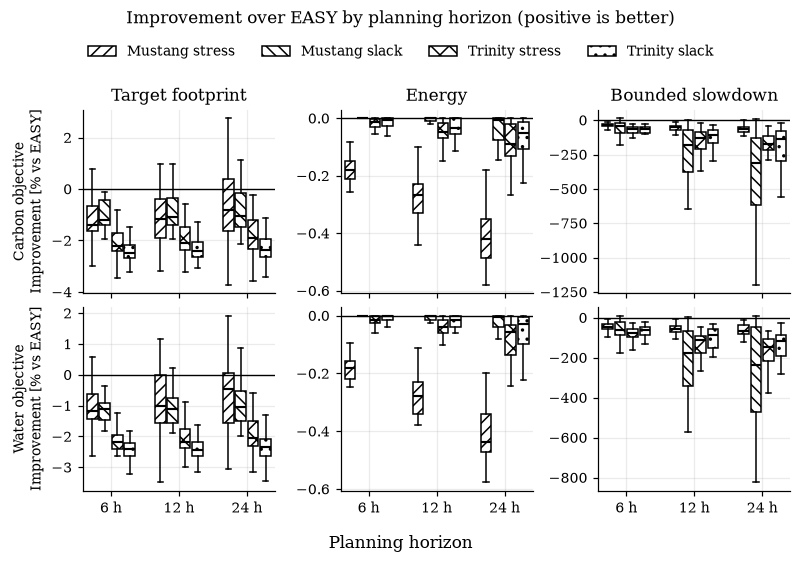

In [8]:
improvement_fig, _ = ca.plot_improvement_vs_easy(paired)
plt.show()

## Plot: scheduling cost

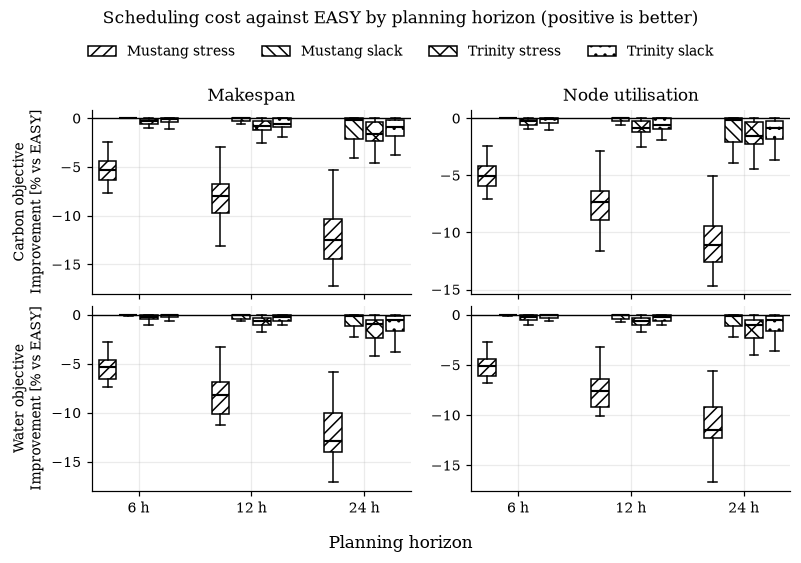

In [9]:
cost_fig, _ = ca.plot_cost_vs_easy(paired)
plt.show()

## Plot: intensity decomposition

Symmetric log axes show positive improvements, negative changes and zero, with a linear interval from -0.1% to +0.1%.


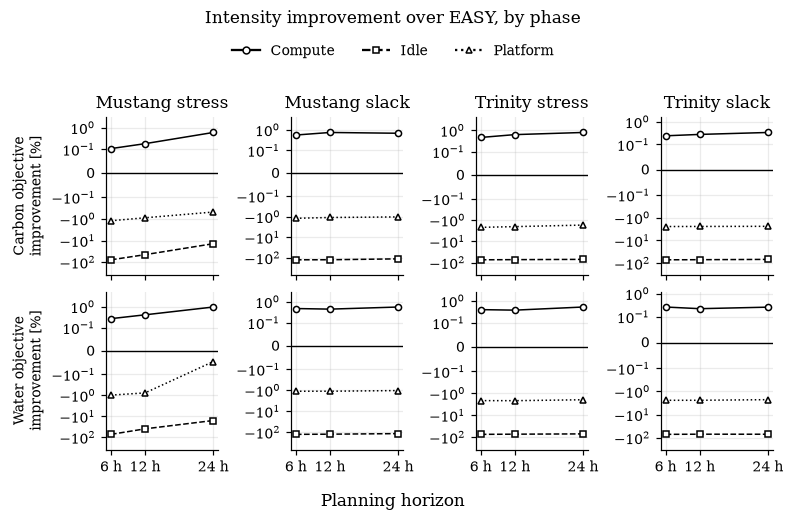

In [10]:
decomposition_fig, _ = ca.plot_intensity_decomposition(paired)
plt.show()

### Compute and idle exposure

Separate rows show compute and idle shares of node-time and energy. Each pair sums to 100% per run; energy shares weight the phases in platform intensity.

C and W denote carbon and water objectives; 6h, 12h and 24h denote planning horizons. EASY appears once per workload. Linear axes fit each panel's full data range, including outliers. Compare tick values across panels because their limits differ.

Node-time sums time across nodes, not elapsed duration or job waiting time. For this always-on campaign, idle node-time is `makespan * number_of_nodes - time_computing`. This includes final idle intervals omitted by the exported counter.


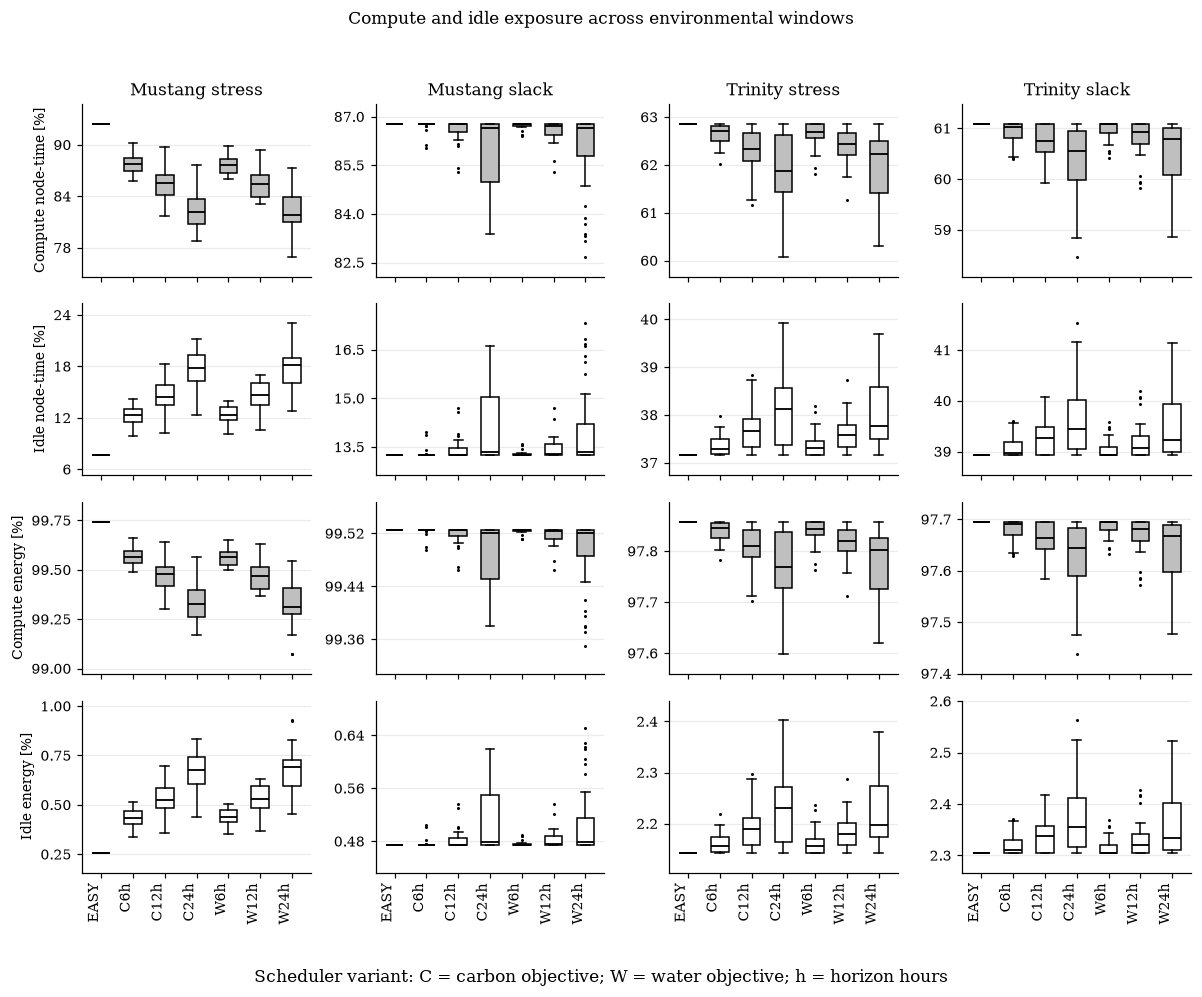

In [11]:
exposure_fig, _ = ca.plot_phase_exposure(run_metrics)
plt.show()

## Plot: footprint versus slowdown

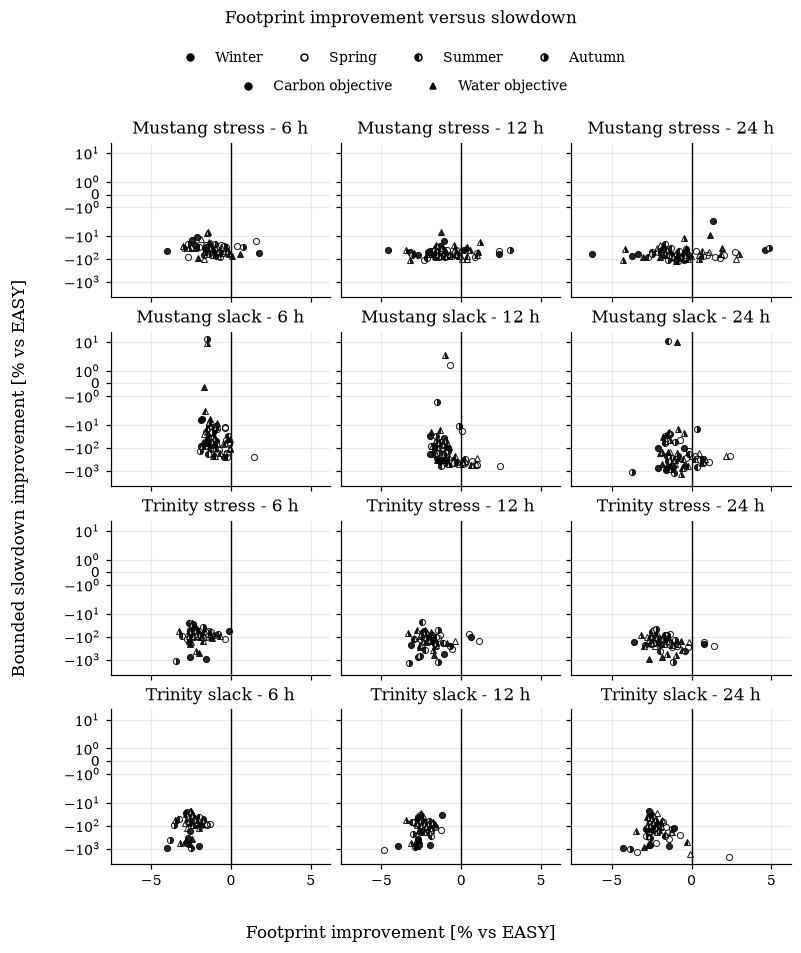

In [12]:
tradeoff_fig, _ = ca.plot_tradeoff_scatter(
    paired,
    "footprint_improvement_pct",
    "Footprint improvement [% vs EASY]",
    "Footprint improvement versus slowdown",
)
plt.show()

## Findings

The campaign uses batsched `ffe1b9f` and 48-day traces, with 864 green runs paired against 144 EASY baselines. Unless stated otherwise, changes are relative to EASY in the same window, with positive values indicating improvement.

All 1008 runs finish within their traces. The maximum makespan is 0.766 of the trace length, so no footprint is charged against a frozen signal.

Compute intensity improves by 0.35% to 0.55%, indicating execution in cleaner periods. Idle intensity worsens by 70% to 78%, offsetting the compute benefit. Platform intensity changes by -1.36% to -1.70% and footprint by -1.48% to -1.76%. Footprint improves in 1.4% to 15.3% of windows.

Energy changes by -0.01% to -0.09% and makespan by -0.20% to -1.71%, while bounded slowdown worsens by 52% to 130%. The energy and makespan changes are small relative to the slowdown penalty.

From 6h to 24h, compute intensity improvement rises from 0.35% to 0.55%, idle intensity improvement changes from -78% to -70%, and footprint improvement changes from -1.70% to -1.48%. The share of windows with lower footprint rises from 3.5% to 15.3%, but the aggregate footprint remains worse than EASY.

On the ceiling metric, EASY's carbon saving is -1.90% relative to the baseline without queueing. Green scheduling reaches -3.76% at 6h and -6.15% at 24h, against bounds of +2.83% and +6.76%. The gap increases from 6.59 to 12.91 percentage points. Water follows the same trend.

## Compute and idle contributions

Both examples compare the carbon objective with a 24-hour planning horizon against EASY, using the German (DE) trace window starting 2019-02-04. The workloads are `trinity_slack` and `mustang_stress`. These are individual experiment pairs, not campaign averages.

The code below selects the four experiment IDs and reproduces the comparisons. Positive changes indicate increases; negative changes indicate decreases.


In [13]:
example_pairs = {
    "trinity_slack": (
        "easy_bf_trinity_slack_DE_2019-02-04",
        "green_window_scheduling_carbon_86400_trinity_slack_DE_2019-02-04",
    ),
    "mustang_stress": (
        "easy_bf_mustang_stress_DE_2019-02-04",
        "green_window_scheduling_carbon_86400_mustang_stress_DE_2019-02-04",
    ),
}
examples = run_metrics.set_index("name")
assert examples.index.is_unique

for workload, (easy_id, green_id) in example_pairs.items():
    easy, green = examples.loc[easy_id], examples.loc[green_id]
    compute_change = 100 * (green.compute_carbon / easy.compute_carbon - 1)
    carbon_change = 100 * (
        green.total_carbon_operational / easy.total_carbon_operational - 1
    )
    idle_intensity_change = 100 * (
        green.idle_carbon_intensity / easy.idle_carbon_intensity - 1
    )
    print(f"{workload}:\n  EASY: {easy_id}\n  Green: {green_id}")
    print(f"  Compute energy: {easy.compute_energy_kwh:,.0f} -> "
          f"{green.compute_energy_kwh:,.0f} kWh; carbon change: {compute_change:+.2f}%")
    print(f"  Idle energy: {easy.idle_energy_kwh:,.0f} -> "
          f"{green.idle_energy_kwh:,.0f} kWh")
    print(f"  Idle carbon intensity: {easy.idle_carbon_intensity:.1f} -> "
          f"{green.idle_carbon_intensity:.1f} gCO2eq/kWh "
          f"({idle_intensity_change:+.0f}%)")
    print(f"  Operational carbon change: {carbon_change:+.2f}%\n")


trinity_slack:
  EASY: easy_bf_trinity_slack_DE_2019-02-04
  Green: green_window_scheduling_carbon_86400_trinity_slack_DE_2019-02-04
  Compute energy: 1,060,134 -> 1,060,134 kWh; carbon change: -1.08%
  Idle energy: 25,011 -> 25,011 kWh
  Idle carbon intensity: 481.8 -> 804.8 gCO2eq/kWh (+67%)
  Operational carbon change: +1.11%

mustang_stress:
  EASY: easy_bf_mustang_stress_DE_2019-02-04
  Green: green_window_scheduling_carbon_86400_mustang_stress_DE_2019-02-04
  Compute energy: 347,609 -> 347,609 kWh; carbon change: -5.91%
  Idle energy: 895 -> 2,240 kWh
  Idle carbon intensity: 678.6 -> 971.9 gCO2eq/kWh (+43%)
  Operational carbon change: -4.58%



On trinity slack, compute energy is unchanged from EASY and compute carbon falls by 1.08%. Idle energy remains 25,011 kWh, but idle intensity rises from 481.8 to 804.8, an increase of 67%. Total carbon increases by 1.11%. With energy unchanged, the carbon increase reflects the change in intensity exposure.

On mustang stress, compute carbon falls by 5.91%. Idle energy rises from 895 to 2,240 kWh and idle intensity from 678.6 to 971.9, while total carbon falls by 4.58%.

Idle footprint can increase through higher idle energy, higher idle intensity, or both.
